# GOAL OF THE PROJECT
The primary objective of this project is to develop a robust and explainable system for the assessment of loan default risk.

# 1. PROBLEM UNDERSTANDING AND DATASET EXPLORATION

In [54]:
!pip install xgboost


In [55]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import shutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')




import zipfile
import os
import pandas as pd

In [56]:

zip_file = "home-credit-default-risk.zip"
extract_to = "data"
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
os.listdir(extract_to)

['application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'HomeCredit_columns_description.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv',
 'sample_submission.csv']

In [57]:

train = pd.read_csv("data/application_train.csv")
prev_app = pd.read_csv("data/previous_application.csv")
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
print("row and column:",train.shape)

row and column: (307511, 122)


In [59]:
print("Train shape:", train.shape)
print(train.head())
print("\nTarget distribution:")
print(train['TARGET'].value_counts(normalize=True))


Train shape: (307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...    

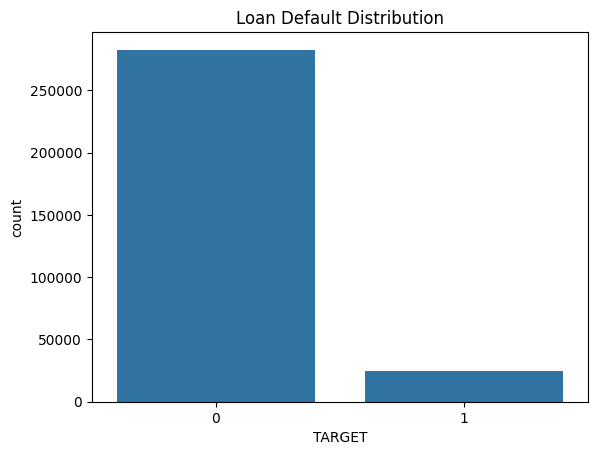

In [60]:
sns.countplot(x='TARGET', data=train)
plt.title("Loan Default Distribution")
plt.show()


# =============================================
2️. DATA PREPROCESSING AND  FEATURE ENGINEERING  
==============================================

In [61]:
bureau = pd.read_csv("data/bureau.csv")
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [62]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'DAYS_CREDIT': ['min','max','mean'],
    'AMT_CREDIT_SUM': ['sum','mean'],
    'AMT_CREDIT_SUM_OVERDUE': ['sum','max'],
    'CNT_CREDIT_PROLONG': ['sum'],
    'CREDIT_ACTIVE': lambda x: (x=='Active').sum()
})
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg.reset_index(inplace=True)

train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')


In [63]:
print("row and column:",train.shape)

row and column: (307511, 131)


In [64]:
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'AMT_APPLICATION': ['sum','mean'],
    'AMT_CREDIT': ['sum','mean'],
    'AMT_ANNUITY': ['sum','mean'],
    'DAYS_DECISION': ['min','max','mean'],
    'CNT_PAYMENT': ['sum']  # if exists
})
prev_agg.columns = ['_'.join(col).strip() for col in prev_agg.columns.values]
prev_agg.reset_index(inplace=True)

train = train.merge(prev_agg, on='SK_ID_CURR', how='left')


In [65]:
print("row and column:",train.shape)

row and column: (307511, 141)


In [66]:
train['CREDIT_INCOME_RATIO'] = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']

In [67]:
train.duplicated().sum()

np.int64(0)

In [68]:
train.info()
missing_value=train.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_value / len(train)) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 143 entries, SK_ID_CURR to ANNUITY_INCOME_RATIO
dtypes: float64(86), int64(41), object(16)
memory usage: 335.5+ MB


In [69]:
missing_df = pd.DataFrame({
    "Missing Count": missing_value,
    "Missing %": missing_percent
})
missing_df = missing_df.sort_values(by="Missing Count", ascending=False)
missing_df.head()

,Missing Count,Missing %
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963


In [70]:
threshold = 0.5
missing_percent = train.isnull().mean() 
drop_cols = missing_percent[missing_percent > threshold].index
train = train.drop(columns=drop_cols)
print("Columns dropped:", drop_cols)
print("Remaining columns:", train.shape)


Columns dropped: Index(['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
       'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
       'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE',
       'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI',
       'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE'],
      dtype='object')
Remaining columns: (307511, 102)


In [71]:
from sklearn.impute import SimpleImputer
num_cols = train.select_dtypes(exclude='object').columns.drop('TARGET')
num_imputer = SimpleImputer(strategy='median')
train[num_cols] = num_imputer.fit_transform(train[num_cols])
print("numberic column:",num_cols)

numberic column: Index(['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE',
       'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG',
       'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMAX_MODE',
       'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMAX_MEDI', 'TOTALAREA_MODE',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
      

In [72]:
cat_cols = train.select_dtypes(include='object').columns
cat_imputer = SimpleImputer(strategy='most_frequent')
train[cat_cols] = cat_imputer.fit_transform(train[cat_cols])
print("categorical columns:",cat_cols)

categorical columns: Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
       'EMERGENCYSTATE_MODE'],
      dtype='object')


In [73]:
train[cat_cols].nunique()

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
EMERGENCYSTATE_MODE            2
dtype: int64

In [74]:
train.isnull().sum().sum()


np.int64(0)

In [75]:
train.isnull().sum()

SK_ID_CURR              0
TARGET                  0
NAME_CONTRACT_TYPE      0
CODE_GENDER             0
FLAG_OWN_CAR            0
                       ..
DAYS_DECISION_max       0
DAYS_DECISION_mean      0
CNT_PAYMENT_sum         0
CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
Length: 102, dtype: int64

In [76]:
binary_cols = [col for col in cat_cols if train[col].nunique() == 2]
multi_cols = [col for col in cat_cols if train[col].nunique() > 2]
print("Binary columns:",binary_cols)
print("multiple columns:",multi_cols)


Binary columns: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']
multiple columns: ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


In [77]:
from sklearn.preprocessing import LabelEncoder
for col in binary_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    train[binary_cols].head()

In [78]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown='ignore',
     sparse_output=False,
      drop='first'
)

encoded_multi = ohe.fit_transform(train[multi_cols])

encoded_multi_df = pd.DataFrame(
    encoded_multi,
    columns=ohe.get_feature_names_out(multi_cols),
    index=train.index,
 
)
encoded_multi_df.head()

,CODE_GENDER_M,CODE_GENDER_XNA,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:

num_cols =train.select_dtypes(include=['number']).columns.drop('TARGET')
X = pd.concat(
    [train[num_cols], train[binary_cols], encoded_multi_df],
    axis=1
)
y =train['TARGET']

print(X.shape, y.shape)


(307511, 205) (307511,)


In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)
print(X_train.shape, X_test.shape)


(246008, 205) (61503, 205)


# =====================================================
3️ MODEL IMPLEMENTATION 
=======================================================

## RandomForest implementation

 Random Forest is a machine-learning algorithm that combines many decision trees to make more accurate and stable predictions than a single tree.

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [82]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)




,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### xgboost implementation

XGBoost (eXtreme Gradient Boosting) is a high-performance machine-learning algorithm that builds trees sequentially, where each new tree focuses on correcting the mistakes of the previous ones.


In [83]:

from xgboost import XGBClassifier
import numpy as np
X_train_np = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
y_train_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
X_test_np = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
y_test_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
scale_pos_weight = (y_train_np == 0).sum() / (y_train_np == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method="hist"
)
xgb_model.fit(X_train_np, y_train_np)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## The main difference between Random Forest and XGBoost is how the trees are built and how they learn from mistakes.

# =====================================================
4️. MODEL EVALUATION AND RESULTS
=======================================================

# RandomForest Evaluation

In [84]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
y_pred_train = rf.predict(X_train)     
y_pred_test  = rf.predict(X_test)
y_prob_test  = rf.predict_proba(X_test)[:, 1]
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_prob_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("Train Accuracy :", train_acc)
print("Test Accuracy  :", test_acc)
print("Precision     :", precision)
print("Recall        :", recall)
print("F1-score      :", f1)
print("ROC-AUC       :", roc_auc)

Train Accuracy : 0.9426156872947221
Test Accuracy  : 0.8797457034616197
Precision     : 0.26683291770573564
Recall        : 0.28016112789526687
F1-score      : 0.2733346433483985
ROC-AUC       : 0.7456373396185125


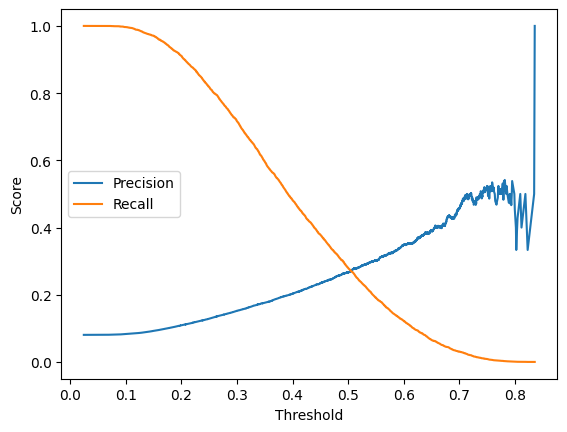

In [85]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()



In [86]:
from sklearn.metrics import precision_recall_curve
import numpy as np
y_prob_test = rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test)
diff = np.abs(precision[:-1] - recall[:-1])
best_index = diff.argmin()
best_threshold = thresholds[best_index]
print("Threshold where precision ≈ recall:", best_threshold)
y_pred_test = (y_prob_test >= best_threshold).astype(int)

Threshold where precision ≈ recall: 0.5050432728633425


In [87]:
y_prob_train = rf.predict_proba(X_train)[:, 1]
y_prob_test = rf.predict_proba(X_test)[:, 1]
threshold = 0.55
y_pred_train = (y_prob_train >= threshold).astype(int)
y_pred_test  = (y_prob_test  >= threshold).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
print("Accuracy :", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall   :", recall_score(y_test, y_pred_test))
print("F1-score :", f1_score(y_test, y_pred_test))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


Accuracy : 0.8989805375347544
Precision: 0.3017789072426938
Recall   : 0.19133937562940584
F1-score : 0.234192037470726
ROC-AUC  : 0.7456373396185125

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95     56538
           1       0.30      0.19      0.23      4965

    accuracy                           0.90     61503
   macro avg       0.62      0.58      0.59     61503
weighted avg       0.88      0.90      0.89     61503



# XGBooST Evaluation

In [88]:

y_pred_train = xgb_model.predict(X_train_np)
y_pred_test  = xgb_model.predict(X_test_np)
y_prob_test = xgb_model.predict_proba(X_test_np)[:, 1]


In [89]:
print("Train Accuracy :", accuracy_score(y_train_np, y_pred_train))
print("Test Accuracy  :", accuracy_score(y_test_np, y_pred_test))
print("Precision     :", precision_score(y_test_np, y_pred_test))
print("Recall        :", recall_score(y_test_np, y_pred_test))
print("F1-score      :", f1_score(y_test_np, y_pred_test))
print("ROC-AUC       :", roc_auc_score(y_test_np, y_prob_test))
print("\nClassification Report:\n")
print(classification_report(y_test_np, y_pred_test))


Train Accuracy : 0.7739260511853273
Test Accuracy  : 0.7488415199258572
Precision     : 0.18461908773618968
Recall        : 0.617925478348439
F1-score      : 0.28429782699346706
ROC-AUC       : 0.761957769617789

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.18      0.62      0.28      4965

    accuracy                           0.75     61503
   macro avg       0.57      0.69      0.57     61503
weighted avg       0.90      0.75      0.80     61503



In [90]:

y_pred_best = (y_prob_test >= 0.3).astype(int)
from sklearn.metrics import precision_score, recall_score, classification_report, accuracy_score, roc_auc_score
print("Accuracy :", accuracy_score(y_test_np, y_pred_best))
print("Precision:", precision_score(y_test_np, y_pred_best))
print("Recall   :", recall_score(y_test_np, y_pred_best))
print("F1-score :", f1_score(y_test_np, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test_np, y_prob_test))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_best))


Accuracy : 0.5012438417638164
Precision: 0.125
Recall   : 0.8630412890231621
F1-score : 0.2183717671040897
ROC-AUC  : 0.761957769617789

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.47      0.63     56538
           1       0.12      0.86      0.22      4965

    accuracy                           0.50     61503
   macro avg       0.55      0.67      0.43     61503
weighted avg       0.91      0.50      0.60     61503



### Model Comparesion 

In [91]:
from sklearn.metrics import precision_recall_curve
import numpy as np
y_prob_test = xgb_model.predict_proba(X_test_np)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test_np, y_prob_test)
diff = np.abs(precision[:-1] - recall[:-1])
best_index = diff.argmin()
best_threshold = thresholds[best_index]

print("Threshold where precision ≈ recall:", best_threshold)

y_pred_test = (y_prob_test >= best_threshold).astype(int)

Threshold where precision ≈ recall: 0.7105666


### Model Comparison --by--Table

In [92]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test_np, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_test),
        precision_score(y_test_np, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_test),
        recall_score(y_test_np, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_test),
        f1_score(y_test_np, y_pred_best)
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, y_pred_test),
        roc_auc_score(y_test_np, y_pred_best)
    ]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.886510,0.29708,0.297080,0.297080,0.617676
1,XGBoost,0.501244,0.12500,0.863041,0.218372,0.666257


### Model Comparison --by--Confusion Matrix

A Confusion Matrix is a table used to evaluate the performance of a classification model by comparing the model’s predictions with the actual (true) labels.

Both models classify class 0 (negative) much better than class 1 (positive), but XGBoost is clearly better at detecting class 1, while Random Forest is more conservative.


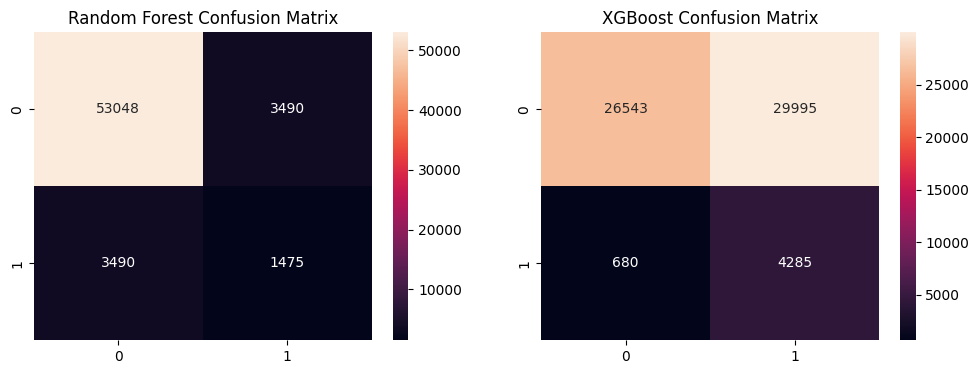

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_test),
            annot=True, fmt="d", ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")

sns.heatmap(confusion_matrix(y_test_np, y_pred_best),
            annot=True, fmt="d", ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")

plt.show()


# MODEL EXPLAINABILITY -- FAIRNESS BY USING SHAP

In [94]:

# SHAP EXPLANATION (FIXED)

import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

X_test_sample = X_test.sample(
    min(200, len(X_test)),
    random_state=42
)

### What this code does (in short)?

It explains a Random Forest model’s predictions using SHAP, focusing on why the model predicts the positive class (TARGET = 1).

This graph explains how the Random Forest model makes predictions for the positive class (TARGET = 1) by showing which features matter most and how their values influence the prediction.

100%|===================| 398/400 [03:39<00:01]        

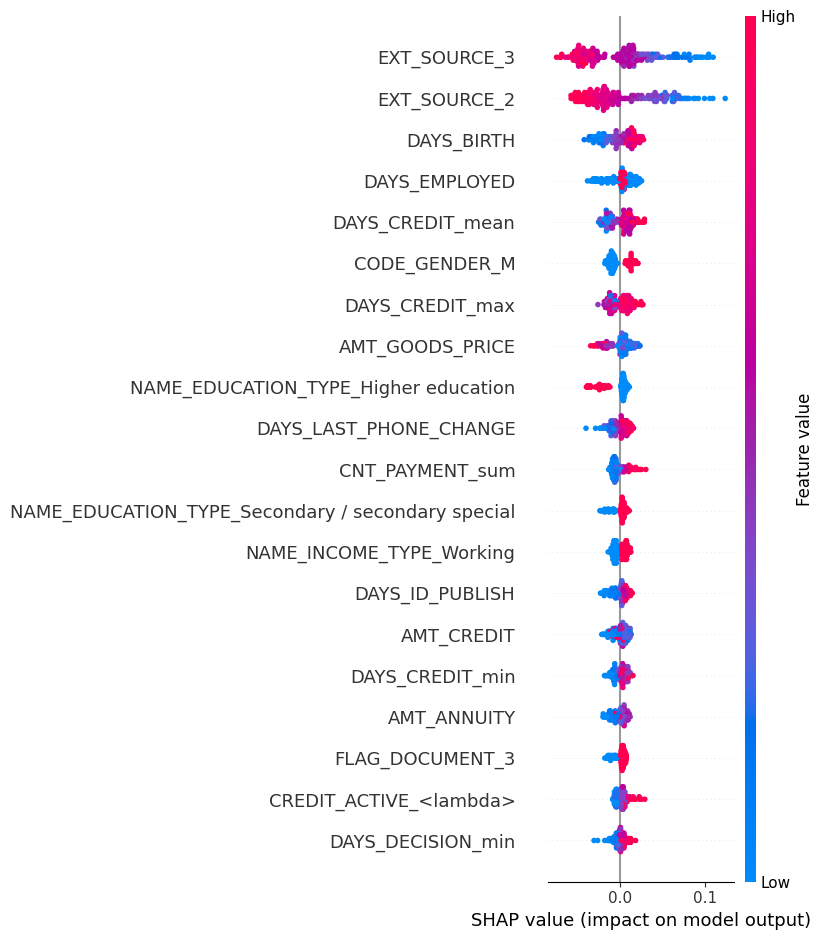

In [95]:
# Use NEW SHAP API

explainer = shap.Explainer(rf, X_train)

shap_values = explainer(X_test_sample)

# Select positive class (TARGET = 1)

shap_values_class1 = shap_values[:, :, 1]

# Base value for class 1

base_value = explainer.expected_value[1]

# 1. SHAP SUMMARY PLOT

shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    max_display=20
)

### This code uses SHAP (SHapley Additive exPlanations) to explain a machine-learning model’s predictions, specifically to identify which features are most important for a given class.

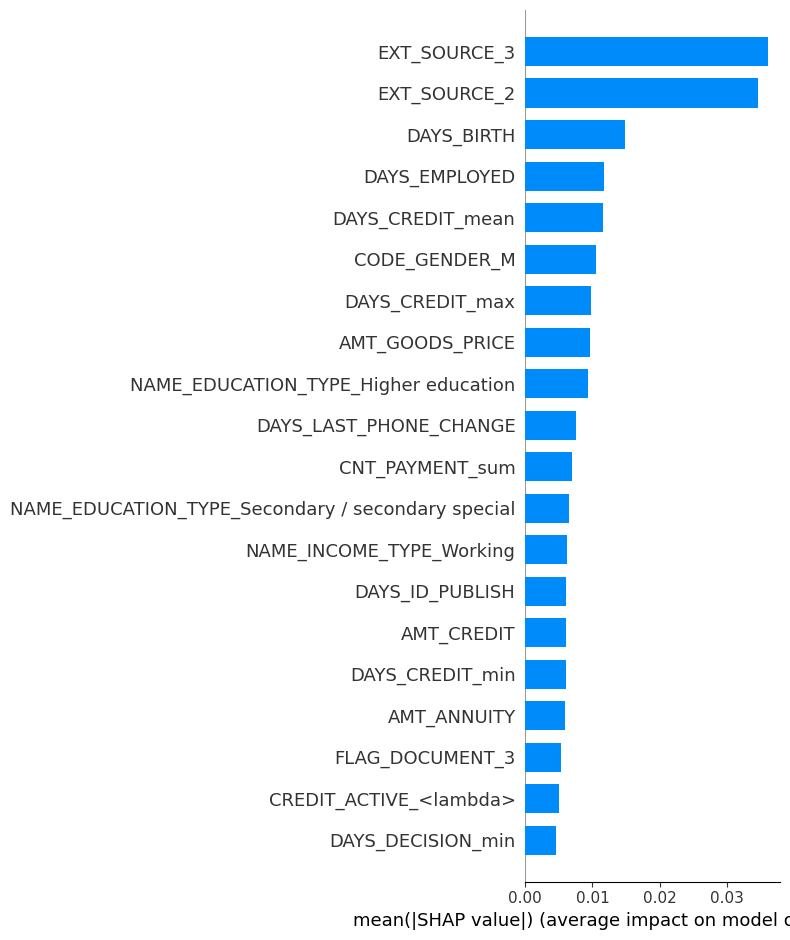


Top 20 Most Important Features:
                                          feature  mean_abs_shap
                                     EXT_SOURCE_3       0.036132
                                     EXT_SOURCE_2       0.034604
                                       DAYS_BIRTH       0.014784
                                    DAYS_EMPLOYED       0.011723
                                 DAYS_CREDIT_mean       0.011631
                                    CODE_GENDER_M       0.010541
                                  DAYS_CREDIT_max       0.009802
                                  AMT_GOODS_PRICE       0.009599
             NAME_EDUCATION_TYPE_Higher education       0.009307
                           DAYS_LAST_PHONE_CHANGE       0.007597
                                  CNT_PAYMENT_sum       0.007024
NAME_EDUCATION_TYPE_Secondary / secondary special       0.006462
                         NAME_INCOME_TYPE_Working       0.006194
                                  DAYS_ID_PUBLISH       0

In [96]:

# 2. SHAP BAR PLOT

shap.summary_plot(
    shap_values_class1,
    X_test_sample,
    plot_type="bar",
    max_display=20
)


# 3. FEATURE IMPORTANCE TABLE

shap_df = (
    pd.DataFrame({
        "feature": X_test_sample.columns,
        "mean_abs_shap": np.abs(shap_values_class1.values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
)

print("\nTop 20 Most Important Features:")
print(shap_df.to_string(index=False))

### This code creates a SHAP waterfall plot — a visualization that explains one specific prediction for one individual customer. 

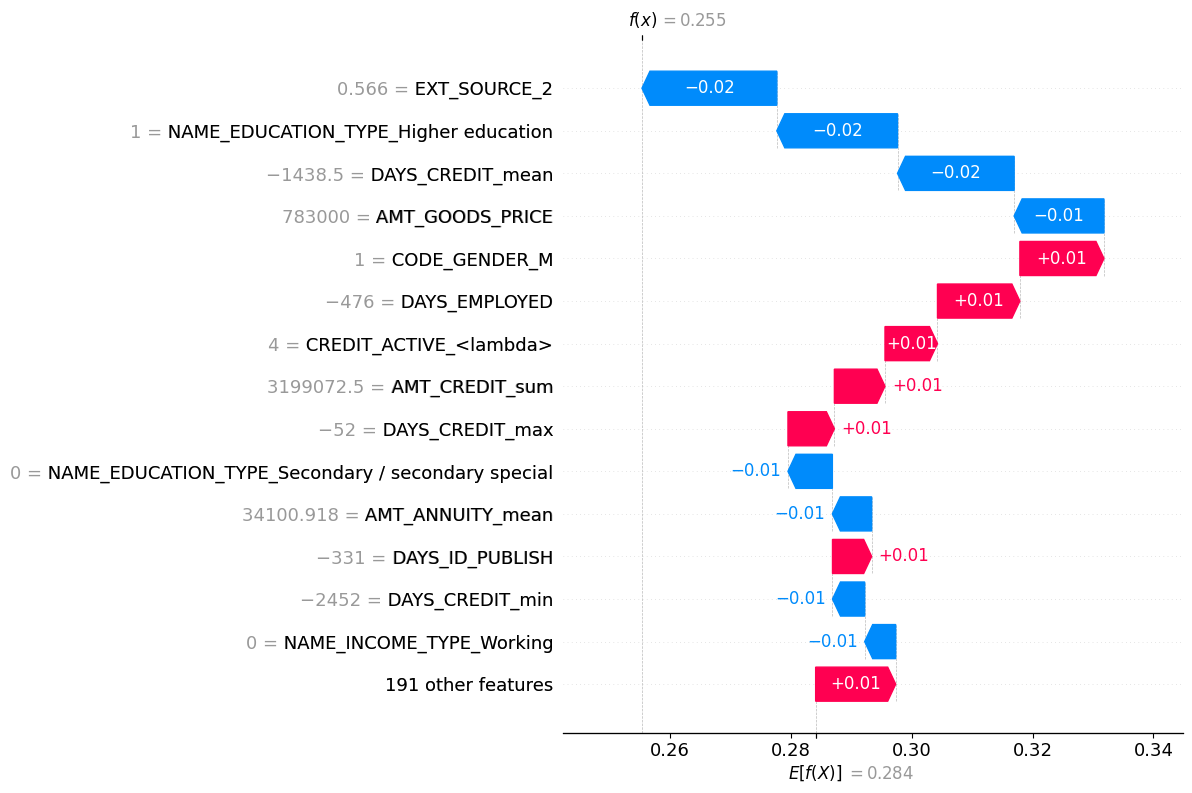

In [97]:

# 4. LOCAL EXPLANATION (WATERFALL)

idx = 0  # choose any index

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_class1.values[idx],
        base_values=base_value,
        data=X_test_sample.iloc[idx],
        feature_names=X_test_sample.columns
    ),
    max_display=15
)

### SHAP Dependence Plot Code Explanation
 This code creates a SHAP dependence plot to visualize how a feature interacts with another feature to affect model predictions.
 This is a SHAP dependence plot showing how three different external credit scores affect a model's predictions.
 
 In banking/credit risk models, EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 are external credit scores or risk metrics provided by third-party agencies (like credit bureaus or specialized scoring companies).

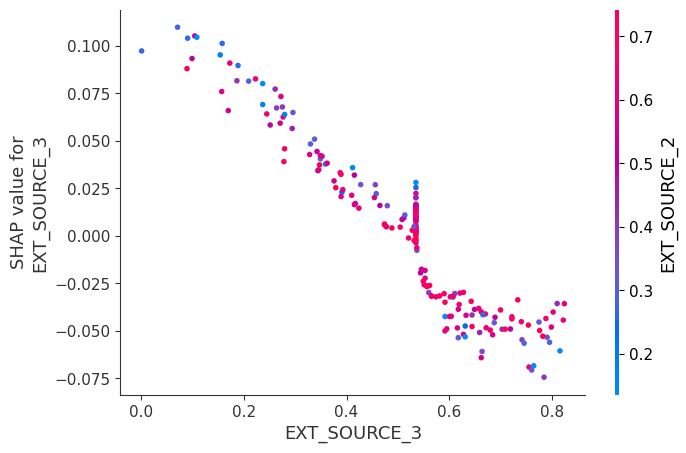

In [98]:

# 5. FEATURE INTERACTION

top_feature = shap_df.iloc[0]["feature"]
second_feature = shap_df.iloc[1]["feature"]

shap.dependence_plot(
    top_feature,
    shap_values_class1.values,
    X_test_sample,
    interaction_index=second_feature
)

### This code generates a SHAP force plot to visually explain a single, individual prediction made by the machine learning model.

 higher → Features pushing the prediction higher (e.g., higher risk of default)

lower → Features pushing the prediction lower (e.g., lower risk)

f(x) → The model's predicted output for this specific customer

base value → The average prediction of the model over all customers (baseline)

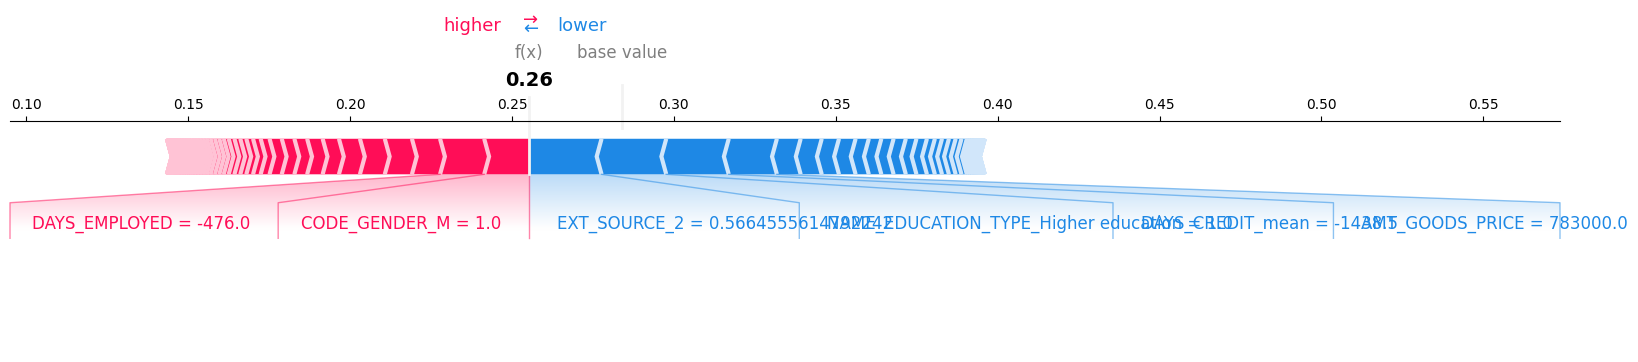

In [99]:

# SHAP FORCE PLOT (FIXED)

index = 0  # any row index from X_test_sample

shap.force_plot(
    base_value,
    shap_values_class1.values[index],
    X_test_sample.iloc[index],
    matplotlib=True
)


### This code generates a SHAP heatmap visualization for interpreting a machine learning model's predictions.

A SHAP heatmap is a matrix-style visualization that shows SHAP (SHapley Additive exPlanations) values for many samples (rows) and many features (columns) simultaneously. It's like combining hundreds of individual force plots into one powerful summary view.
 

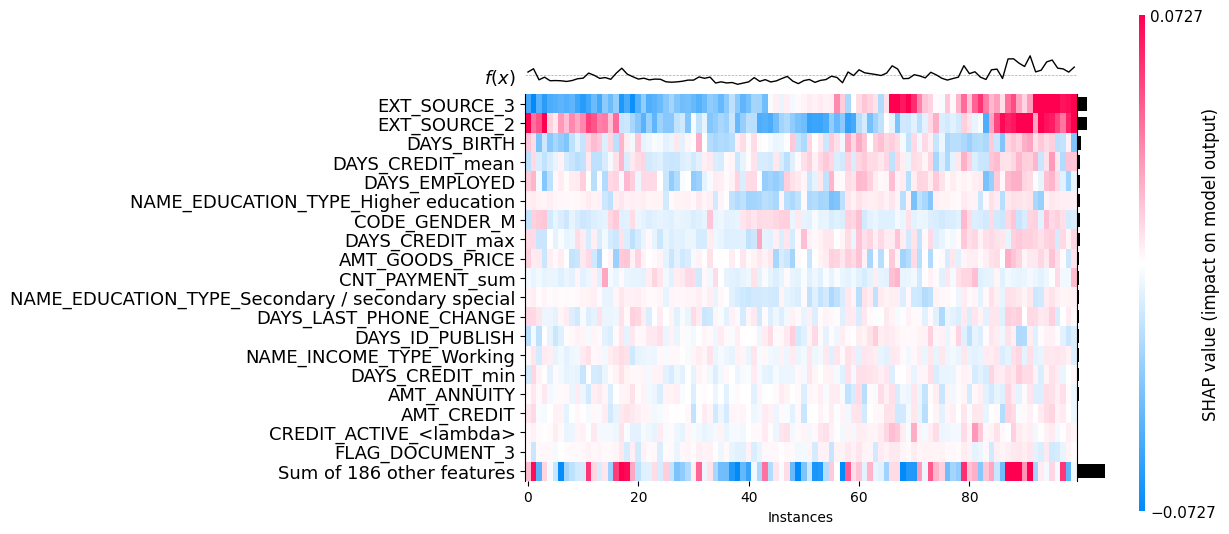

<Axes: xlabel='Instances'>

In [100]:

# 6. SHAP HEATMAP

shap.plots.heatmap(
    shap.Explanation(
        values=shap_values_class1.values[:100],
        base_values=base_value,
        data=X_test_sample.iloc[:100],
        feature_names=X_test_sample.columns
    ),
    max_display=20
)